In [1]:
import torch
from torch import nn, optim
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt


In [2]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()  
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,  
    download=True,
    transform=ToTensor()  
)

100.0%


Extracting data\FashionMNIST\raw\train-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw



Image shape: torch.Size([64, 1, 28, 28])
Label: torch.Size([64])


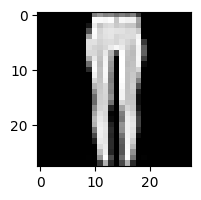

In [ ]:
train_loader = DataLoader(training_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

for images, labels in train_loader:
    print(f"Image shape: {images.shape}")
    print(f"Label: {labels.shape}")
    break

plt.figure(figsize=(2,2))  
plt.imshow(images[4].squeeze(), cmap='gray')
plt.show()

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device") 

Using cuda device


In [10]:
class CloathsClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.network(x)

In [14]:
model = CloathsClassifier().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [15]:
epochs = 5
for epoch in range(epochs):
   for batch, (images,labels) in enumerate(train_loader):
       images, labels = images.to(device), labels.to(device)
       predictions = model(images)
       loss = criterion(predictions, labels)
       loss.backward()
       optimizer.step()
       optimizer.zero_grad()

       if batch % 100 == 0:
           print(f"Epoch: {epoch+1}/{epochs}, Batch: {batch}, Loss: {loss.item():.4f}")

Epoch: 1/5, Batch: 0, Loss: 2.3042
Epoch: 1/5, Batch: 100, Loss: 0.6771
Epoch: 1/5, Batch: 200, Loss: 0.4272
Epoch: 1/5, Batch: 300, Loss: 0.4851
Epoch: 1/5, Batch: 400, Loss: 0.3298
Epoch: 1/5, Batch: 500, Loss: 0.4195
Epoch: 1/5, Batch: 600, Loss: 0.6629
Epoch: 1/5, Batch: 700, Loss: 0.3060
Epoch: 1/5, Batch: 800, Loss: 0.4119
Epoch: 1/5, Batch: 900, Loss: 0.4579
Epoch: 2/5, Batch: 0, Loss: 0.5653
Epoch: 2/5, Batch: 100, Loss: 0.6334
Epoch: 2/5, Batch: 200, Loss: 0.4091
Epoch: 2/5, Batch: 300, Loss: 0.1649
Epoch: 2/5, Batch: 400, Loss: 0.3822
Epoch: 2/5, Batch: 500, Loss: 0.7055
Epoch: 2/5, Batch: 600, Loss: 0.3110
Epoch: 2/5, Batch: 700, Loss: 0.3071
Epoch: 2/5, Batch: 800, Loss: 0.4081
Epoch: 2/5, Batch: 900, Loss: 0.3900
Epoch: 3/5, Batch: 0, Loss: 0.2496
Epoch: 3/5, Batch: 100, Loss: 0.5015
Epoch: 3/5, Batch: 200, Loss: 0.4085
Epoch: 3/5, Batch: 300, Loss: 0.5152
Epoch: 3/5, Batch: 400, Loss: 0.3160
Epoch: 3/5, Batch: 500, Loss: 0.4609
Epoch: 3/5, Batch: 600, Loss: 0.4449
Epoch: 

In [16]:
# Testing the model
model.eval()  # Switch to evaluation mode

all_predicted = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        _, predicted = torch.max(outputs.data, 1)
        
        # Append labels and predictions to lists
        all_labels.extend(labels.cpu().numpy())    
        all_predicted.extend(predicted.cpu().numpy()) 

        from sklearn.metrics import classification_report

report = classification_report(all_labels, all_predicted)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1000
           1       1.00      0.94      0.97      1000
           2       0.65      0.85      0.74      1000
           3       0.86      0.84      0.85      1000
           4       0.82      0.52      0.64      1000
           5       0.98      0.89      0.93      1000
           6       0.57      0.64      0.60      1000
           7       0.90      0.97      0.93      1000
           8       0.93      0.97      0.95      1000
           9       0.94      0.96      0.95      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000

